# LSST SN Ia Single-Object Simulation

Forward-model **one** SN Ia light curve at a user-specified sky position and SALT3 parameters
against a DP2 CCDVisit/detector table with `lightcurvelynx`, instead of sampling a population.

**Survey**: DP2 visit-detector table (`DP2_VISIT_DETECTOR_FILE`, the real DP2 `visit_detector.parquet`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Parameters**: fixed RA, Dec, t0, x0, x1, c, and redshift (`OBJECT_PARAMS`) — not sampled.
Set `NUM_REALIZATIONS > 1` to draw multiple independent noise realizations of the same object.

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sfdmap2
# %pip install iminuit

In [3]:
# # setup dustmaps, run once
# from dustmaps.config import config
# config.reset()

In [4]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /home/midai/mdai/lightcurvelynx_rubin_dp2/data


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from nested_pandas import read_parquet
from joblib.externals.loky import get_reusable_executor
import sncosmo
from astropy.cosmology import Planck18
from astropy.coordinates import Distance

from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.math_nodes.given_sampler import TableSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import flux2mag

import lightcurvelynx
print(lightcurvelynx.__version__)

0.5.2.dev5+g39303e74d


/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from nested_pandas import read_parquet
data = read_parquet("data/final_sample_ddf.parquet")

## 2. Simulation Configuration

In [7]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SKIP_SIM = False   # Set to True to skip simulation and load existing results from disk.
SKIP_LCFIT = False # Set to True to skip LC fitting and load existing results from disk.
FIT_Z = True # Fit redshift in SALT fit.
FIT_Z_SUFFIX = "_fitz" if FIT_Z else ""

# The DP2 CCDVisit/detector table has no field/program column, so DDF/WFD visits can't be
# selected by string match (unlike the opsim `observation_reason` column used in
# dp2_sims_ddf.ipynb). Instead, select/exclude by proximity to known DDF field centers.
SELECT_DDF_ONLY = False  # Set to True to keep only visits within DDF_RADIUS_DEG of a DDF field.
SELECT_WFD_ONLY = False  # Set to True to exclude visits within DDF_RADIUS_DEG of a DDF field.
assert not (SELECT_DDF_ONLY and SELECT_WFD_ONLY), "SELECT_DDF_ONLY and SELECT_WFD_ONLY are mutually exclusive."

OUTPUT_SUFFIX = "_ddf" if SELECT_DDF_ONLY else "_wfd" if SELECT_WFD_ONLY else ""  # Tag output filenames.

SIM_PARAMS = {
    "filters": ["u", "g", "r", "i", "z", "y"],
}

NUM_REALIZATIONS = 100  # increase to draw multiple independent noise realizations of the same object

# Edit the values below to specify the SN Ia to simulate. RA/Dec must fall within the loaded
# visit table's footprint (see Section 3's coverage/footprint plot), and t0 should fall within
# the survey's MJD range (see Section 3's printed range), for any observations to be found.
OBJECT_PARAMS = {
    "ra": 150.1167,      # deg — placeholder (COSMOS field, known within DP2 footprint); edit as needed
    "dec": 2.2058,       # deg
    "t0": 60900.0,       # MJD — placeholder; edit to fall within the survey's MJD range
    "x0": 1.0e-5,        # SALT3 amplitude — placeholder
    "x1": 0.0,
    "c": 0.0,
    "redshift": 0.1,
}

for key in OBJECT_PARAMS.keys():
    sn = data.iloc[0]
    sn["ra"] = sn["ra_dia_object_lc"]
    sn["dec"] = sn["dec_dia_object_lc"]
    sn["redshift"] = sn["z"]
    OBJECT_PARAMS[key] = sn[key]

print(OBJECT_PARAMS)

{'ra': 148.47186753407226, 'dec': 1.197915196819807, 't0': 61029.9929073371, 'x0': 1.4555180781846333e-05, 'x1': -3.1754501150465417, 'c': 0.08754747472371951, 'redshift': 0.38770896936349564}


## 3. Load LSST Visit Table

Loading the DP2 visit-detector table from `DP2_VISIT_DETECTOR_FILE`.

If `SELECT_DDF_ONLY` is `True`, visits are restricted to those within `DDF_RADIUS_DEG` of a
known Deep Drilling Field center (COSMOS, ECDFS, EDFS a/b, ELAIS-S1, XMM-LSS). If
`SELECT_WFD_ONLY` is `True`, those DDF visits are excluded instead, leaving only the wide-fast-deep
survey. The CCDVisit table has no `observation_reason`/field column to filter on directly, so
this selection is done by sky position instead.

In [8]:
DP2_VISIT_DETECTOR_FILE = "/rubin/lsdb_data/dp2/public-files/visit_detector.parquet"
dp2_visit_table = pd.read_parquet(DP2_VISIT_DETECTOR_FILE)

# LSST Deep Drilling Field centers (rubin_scheduler / rubin_sim definitions).
DDF_FIELDS = {
    "COSMOS":   (150.1167, 2.2058),
    "ECDFS":    (53.125,  -28.100),
    "EDFS_a":   (58.90,   -49.315),
    "EDFS_b":   (63.60,   -47.60),
    "ELAIS-S1": (9.45,    -44.00),
    "XMM-LSS":  (35.708,  -4.750),
}
DDF_RADIUS_DEG = 1.75  # matching radius around each DDF field center

def select_ddf_visits(visit_table, ra_col="ra", dec_col="dec"):
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    visit_coords = SkyCoord(ra=visit_table[ra_col].values * u.deg, dec=visit_table[dec_col].values * u.deg)
    is_ddf = np.zeros(len(visit_table), dtype=bool)
    for ra, dec in DDF_FIELDS.values():
        field_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
        is_ddf |= visit_coords.separation(field_coord).deg < DDF_RADIUS_DEG
    return is_ddf

if SELECT_DDF_ONLY:
    n_before = len(dp2_visit_table)
    dp2_visit_table = dp2_visit_table[select_ddf_visits(dp2_visit_table)]
    print(f"Selected {len(dp2_visit_table):,} DDF visits out of {n_before:,} total")
elif SELECT_WFD_ONLY:
    n_before = len(dp2_visit_table)
    dp2_visit_table = dp2_visit_table[~select_ddf_visits(dp2_visit_table)]
    print(f"Selected {len(dp2_visit_table):,} WFD visits out of {n_before:,} total (excluded DDF)")

obstable = LSSTObsTable.from_ccdvisit_table(dp2_visit_table, make_detector_footprint=True)
print(f"Visit table loaded: {len(obstable):,} observations")
print(f"MJD range: {obstable['time'].min():.1f} – {obstable['time'].max():.1f}")
print(f"Filters:    {sorted(obstable['filter'].unique())}")

/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:273: UserWarning: Found NaN values in critical column 'pixelScale'. Dropping rows with NaN values in this column.
  warnings.warn(
/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:273: UserWarning: Found NaN values in critical column 'seeing'. Dropping rows with NaN values in this column.
  warnings.warn(
/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:273: UserWarning: Found NaN values in critical column 'zeroPoint'. Dropping rows with NaN values in this column.
  warnings.warn(


Visit table loaded: 5,004,759 observations
MJD range: 60790.1 – 61047.4
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [9]:
obstable.head()

,detectorId,visitId,physical_filter,filter,ra,dec,pixel_scale,zenithDistance,exptime,zp_mag_adu,...,lrcdec,wcsCornerMaxOffset,wcsDetectorPointingResidual,wcsVisitPointingResidual,wcsPreliminaryDetectorPointingResidual,wcsPreliminaryVisitPointingResidual,radius,zp,psf_footprint,sky_bg_e
0,1,2025042400172,r_57,r,183.924159,6.983400,0.199324,37.089813,29.999916,32.158752,...,6.828384,0.170347,0.744071,6.553011,0.916436,6.759033,0.157980,0.311701,150.325357,2450.773193
1,2,2025042400172,r_57,r,184.119267,7.114777,0.199386,37.218884,29.999916,32.171349,...,6.959794,0.041369,0.706818,5.430327,0.743956,5.477780,0.158029,0.308106,152.484625,2506.839600
2,3,2025042400172,r_57,r,183.860867,6.658387,0.199382,36.765778,29.999916,32.168167,...,6.503267,0.030114,0.667091,6.370576,0.689754,6.432752,0.158026,0.309010,130.565136,2498.805908
3,4,2025042400172,r_57,r,184.056165,6.789660,0.199462,36.894409,29.999916,32.176689,...,6.634574,0.028227,0.661132,6.271190,0.670319,6.300598,0.158089,0.306594,120.875367,2506.594238
4,5,2025042400172,r_57,r,184.251453,6.921106,0.199489,37.024181,29.999916,32.180489,...,6.766038,0.034896,0.656864,5.191592,0.665656,5.237656,0.158111,0.305523,116.177034,2521.336914


In [10]:
t_min = float(obstable["time"].min())
t_max = float(obstable["time"].max())
print(f"Survey MJD range: {t_min:.1f} – {t_max:.1f}")
print(f"Object RA/Dec/t0: {OBJECT_PARAMS['ra']:.4f}, {OBJECT_PARAMS['dec']:.4f}, {OBJECT_PARAMS['t0']:.1f}")
if not (t_min <= OBJECT_PARAMS["t0"] <= t_max):
    print("WARNING: OBJECT_PARAMS['t0'] falls outside the survey MJD range — the light curve may be empty.")

Survey MJD range: 60790.1 – 61047.4
Object RA/Dec/t0: 148.4719, 1.1979, 61030.0


## 4. Load LSST Passbands

In [11]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 5. Build SN Ia Source Model

All SALT3 parameters and the sky position are drawn **in order from `data`** via `TableSampler`,
one row per simulated sample — sample *i* uses `data.iloc[i]`'s (ra, dec, t0, x0, x1, c, redshift),
instead of a single fixed object repeated with independent noise.

Dust extinction (Milky Way, SFD map) is still computed dynamically at each sample's `(ra, dec)` via
`DustmapWrapper`/`ExtinctionEffect`.

In [12]:
# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Pull (ra, dec, t0, x0, x1, c, redshift) for each simulated object in order from `data`,
# one row per sample, instead of a single fixed set of parameters.
assert NUM_REALIZATIONS <= len(data), (
    f"NUM_REALIZATIONS ({NUM_REALIZATIONS}) exceeds the number of rows in data ({len(data)})."
)
param_table_data = data[["ra_dia_object_lc", "dec_dia_object_lc", "z", "t0", "x0", "x1", "c"]].rename(
    columns={"ra_dia_object_lc": "ra", "dec_dia_object_lc": "dec", "z": "redshift"}
)
param_table = TableSampler(param_table_data, in_order=True, node_label="param_table")

# Assemble the SALT3 source (no host galaxy); each sample draws its parameters from the next row of param_table
source = SncosmoWrapperModel(
    "salt3",
    t0=param_table.t0,
    x0=param_table.x0,
    x1=param_table.x1,
    c=param_table.c,
    ra=param_table.ra,
    dec=param_table.dec,
    redshift=param_table.redshift,
    node_label="source",
    time_extrapolation=(time_extrap_before, time_extrap_after),
    wave_extrapolation=(wave_extrap_before, wave_extrap_after),
)

from dustmaps.sfd import SFDQuery
mwextinction = DustmapWrapper(SFDQuery(), ra=source.ra, dec=source.dec, node_label="mwext")
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction,
                              r_v=3.1, frame='observer', backend="dust_extinction")
source.add_effect(ext_effect)

print(f"Source model built successfully — will draw {NUM_REALIZATIONS} object(s) in order from data.")

Source model built successfully — will draw 100 object(s) in order from data.


## 6. Run Simulation

In [13]:
if not SKIP_SIM:
    param_cols = [
        "source.t0",
        "source.x0",
        "source.x1",
        "source.c",
        "source.redshift",
        "source.ra",
        "source.dec",
    ]
    obstable_save_cols = ["zp"]

    NJOBS = 8
    BATCH_SIZE = 3000
    executor = get_reusable_executor(max_workers=4)
    lightcurves = simulate_lightcurves(
        model=source,
        num_samples=NUM_REALIZATIONS,
        survey_info=obstable,
        passbands=passbands,
        param_cols=param_cols,
        obstable_save_cols=obstable_save_cols,
        rng=RNG,
        num_jobs=NJOBS,
        batch_size=BATCH_SIZE,
        executor=executor,
    )
    print(f"Simulated {len(lightcurves):,} realization(s)")
    lightcurves.head()

/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:716: FutureWarning: The passbands argument is deprecated and will be removed from future versions.
  warnings.warn(
/home/midai/mdai/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:728: FutureWarning: Passing ObsTable objects directly in survey_info is deprecated and will be removed in future versions. Please use SurveyInfo objects instead.
  warnings.warn(
Simulating:   0%|          | 0/100 [00:00<?, ?obj/s]/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Simulating: 100%|██████████| 100/100 [00:42<00:00,  2.33obj/s]

Simulated 100 realization(s)


## 7. Save Results

In [14]:
if not SKIP_SIM:
    from pathlib import Path
    output_path = Path(f"outputs/lsst_snia_dp2_singleobject{OUTPUT_SUFFIX}_results.parquet")
    output_path.parent.mkdir(exist_ok=True)
    lightcurves.to_parquet(output_path)
    print(f"Saved to {output_path}")

Saved to outputs/lsst_snia_dp2_singleobject_results.parquet


In [15]:
lightcurves = read_parquet(f"outputs/lsst_snia_dp2_singleobject{OUTPUT_SUFFIX}_results.parquet")
lightcurves = lightcurves.drop(columns=["params"]).dropna(subset=['lightcurve'])
print(f"Loaded {len(lightcurves):,} realization(s) with a valid lightcurve")

Loaded 100 realization(s) with a valid lightcurve


## 8. Diagnostics

Inspect the simulated light curve(s) and fit them back with SALT3 to check parameter recovery.

In [16]:
results = lightcurves

              mjd filter         flux      fluxerr  flux_perfect  survey_idx  \
0    60811.047318      i    -8.894130   429.941056      0.000000           0   
1    60811.047791      i  -273.062028   303.421834      0.000000           0   
..            ...    ...          ...          ...           ...         ...   
125  61043.195148      y  3426.714102  1546.265075   1636.236443           0   
126  61043.195646      y -1124.640642  1209.583542   1636.183656           0   

     obs_idx  is_saturated        zp  
0     538378         False  0.516901  
1     538556         False  0.410754  
..       ...           ...       ...  
125  4821241         False  1.569545  
126  4821419         False  1.513728  

[127 rows x 9 columns]


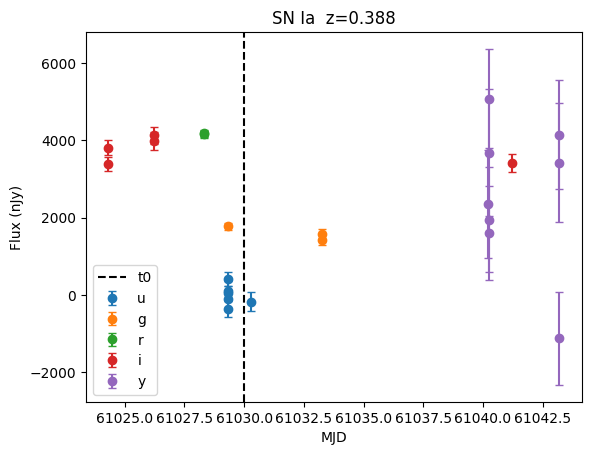

In [17]:
# example light curve for the (first) simulated realization
sn = results.iloc[0]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

In [18]:
def infer_z_from_peakmag(row):
    peakflux = np.max(row)
    peakmag = flux2mag(peakflux)
    z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
    return z

In [19]:
# append system path 

from utils.lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.4),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [20]:
lc_to_fit = results.iloc[0:]

In [21]:
lc_to_fit = lc_to_fit.map_rows(infer_z_from_peakmag, columns=["lightcurve.flux"], row_container="args",
                     output_names=["z_est"], append_columns=True)

In [22]:
res = fit_single_lc_w_cond(lc_to_fit.iloc[0])
res

success       1.0
ncall        66.0
             ... 
id            0.0
fit_error     NaN
Length: 54, dtype: float64

In [23]:
%%time
if not SKIP_LCFIT:
    executor = get_reusable_executor(max_workers=min(NUM_REALIZATIONS, 4), kill_workers=True)
    futures = [executor.submit(fit_single_lc_w_cond, row) for _index, row in lc_to_fit.iterrows()]
    fit_results = [f.result() for f in futures]
    result_df = pd.DataFrame(fit_results)

/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/home/midai/.conda/envs/lynx/lib/python3.12/site-packages/sncosm

CPU times: user 481 ms, sys: 26 ms, total: 508 ms
Wall time: 1min 33s


In [24]:
if not SKIP_LCFIT:
    result_df.to_csv(f"outputs/lsst_snia_dp2_singleobject{OUTPUT_SUFFIX}_lcfit_results{FIT_Z_SUFFIX}.csv", index=True)
    print(f"Saved {len(result_df)} LC fit results")

Saved 100 LC fit results


In [25]:
result_df = pd.read_csv(f"outputs/lsst_snia_dp2_singleobject{OUTPUT_SUFFIX}_lcfit_results{FIT_Z_SUFFIX}.csv")

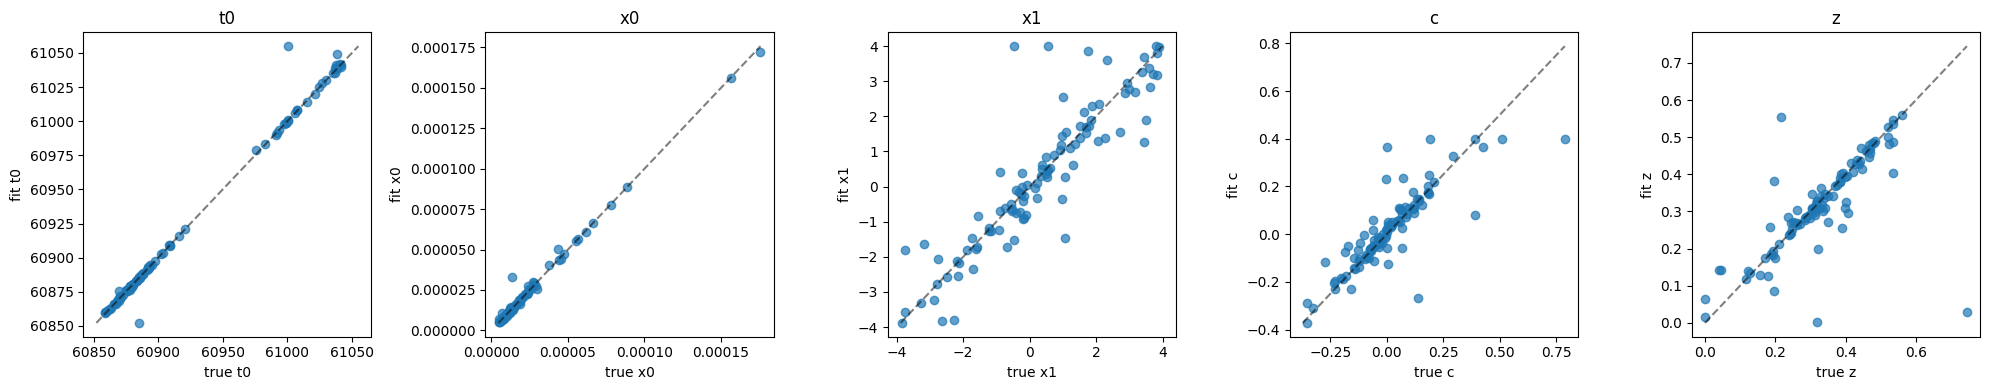

,Unnamed: 0,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,...,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,id,fit_error
0,0,1.0,66.0,29.394788,19.0,0.399663,0.018998,61030.374541,0.614938,0.000014,...,1.133726e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,1,1.0,138.0,14.451396,12.0,0.381194,0.012950,61038.968962,1.552176,0.000007,...,1.668360e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,98,1.0,136.0,379.626731,317.0,0.296692,0.008533,60859.861146,0.583741,0.000009,...,5.321939e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,98.0,NaN
99,99,1.0,127.0,111.091088,111.0,0.467892,0.012714,61005.764874,0.211477,0.000011,...,1.856451e-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.0,NaN


In [26]:
# Compare the SALT3 fit against the true (fixed) input parameters
# Each simulated sample i corresponds to data.iloc[i] (TableSampler draws in order),
# so match fit results to true values positionally.
params = ["t0", "x0", "x1", "c", "z"]
true_df = data.iloc[:len(result_df)][params].reset_index(drop=True)
fit_df = result_df[params].reset_index(drop=True)

fig, axes = plt.subplots(1, len(params), figsize=(4 * len(params), 4))
for ax, p in zip(axes, params):
    true_vals = true_df[p]
    fit_vals = fit_df[p]
    ax.scatter(true_vals, fit_vals, alpha=0.7)
    lims = [min(true_vals.min(), fit_vals.min()), max(true_vals.max(), fit_vals.max())]
    ax.plot(lims, lims, "k--", alpha=0.5)
    ax.set_xlabel(f"true {p}")
    ax.set_ylabel(f"fit {p}")
    ax.set_title(p)
plt.tight_layout()
plt.show()
result_df

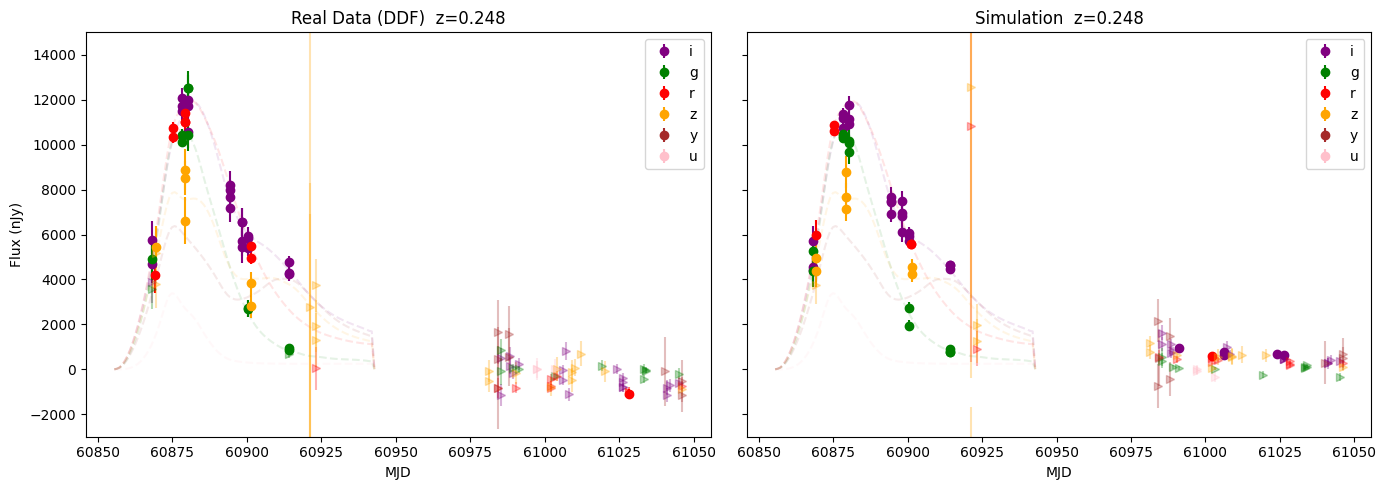

In [46]:
# Compare the real observed light curve against the simulated one, with the shared
# SALT3 + MW-dust model overplotted on both (both use the same real object's fitted
# parameters, since OBJECT_PARAMS was seeded from this row above).
i=10
sn = data.iloc[i]
saltpars = {"z": sn["z"], "t0": sn["t0"], "x0": sn["x0"], "x1": sn["x1"], "c": sn["c"], "mwebv": sn["mwebv"]}

data_lc = pd.DataFrame(sn["diaObjectForcedSource_dia_object_lc"]).rename(
    columns={"midpointMjdTai": "mjd", "psfDiffFlux": "flux", "psfDiffFluxErr": "fluxerr"}
)

sim_lc = results.iloc[i]["lightcurve"].rename(columns={"filter": "band"})
sim_lc["snr"] = sim_lc["flux"] / sim_lc["fluxerr"]

colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}

def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    # plt.ylim(ylim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plt.sca(axes[0])
plot_lc(data_lc, saltpars)
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f"Real Data (DDF)  z={saltpars['z']:.3f}")
plt.sca(axes[1])
plot_lc(sim_lc, saltpars)
plt.xlabel("MJD")
plt.title(f"Simulation  z={saltpars['z']:.3f}")
plt.ylim((-3000,15000))
plt.tight_layout()
plt.show()

Matched 117 points across 6 band(s)


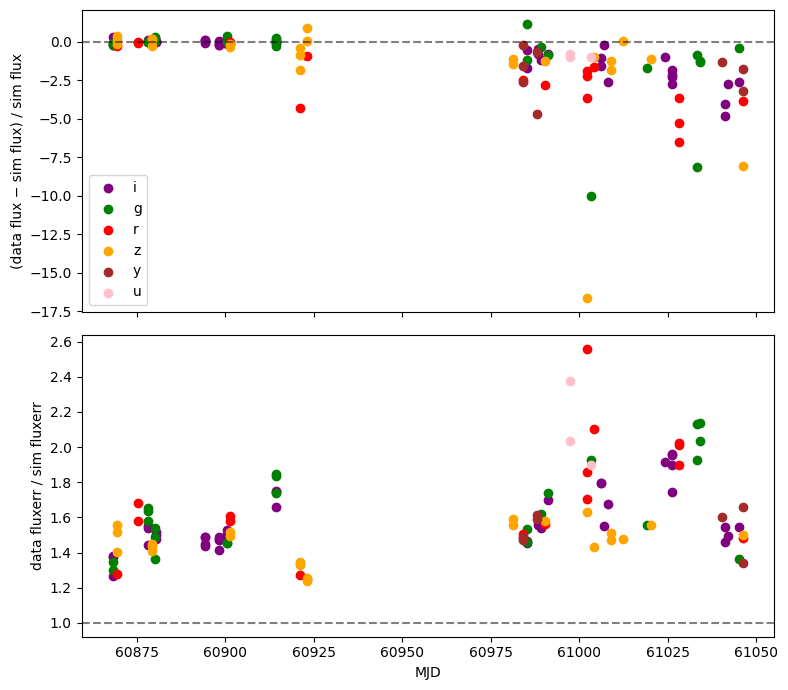

In [47]:
# Match real and simulated points per band by nearest MJD (both are drawn from the
# same survey's visit epochs at this sky position, so timestamps should align closely),
# then compare flux residuals and flux-error ratios.
merged_list = []
for band in sim_lc["band"].unique():
    d = data_lc.loc[data_lc["band"] == band].sort_values("mjd")
    s = sim_lc.loc[sim_lc["band"] == band].sort_values("mjd")
    if d.empty or s.empty:
        continue
    m = pd.merge_asof(s[["mjd", "flux", "fluxerr"]], d[["mjd", "flux", "fluxerr"]],
                       on="mjd", direction="nearest", tolerance=0.01,
                       suffixes=("_sim", "_data"))
    m = m.dropna(subset=["flux_data"])
    m["band"] = band
    merged_list.append(m)

merged = pd.concat(merged_list, ignore_index=True) if merged_list else pd.DataFrame(
    columns=["mjd", "flux_sim", "fluxerr_sim", "flux_data", "fluxerr_data", "band"]
)
merged["flux_resid"] = (merged["flux_data"] - merged["flux_sim"]) / merged["flux_sim"]
merged["fluxerr_ratio"] = merged["fluxerr_data"] / merged["fluxerr_sim"]
print(f"Matched {len(merged)} points across {merged['band'].nunique()} band(s)")

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
for band in merged["band"].unique():
    m = merged.loc[merged["band"] == band]
    axes[0].scatter(m["mjd"], m["flux_resid"], label=band, c=colors[band])
    axes[1].scatter(m["mjd"], m["fluxerr_ratio"], label=band, c=colors[band])
axes[0].axhline(0, ls="--", color="k", alpha=0.5)
axes[0].set_ylabel("(data flux − sim flux) / sim flux")
axes[0].legend()
axes[1].axhline(1, ls="--", color="k", alpha=0.5)
axes[1].set_ylabel("data fluxerr / sim fluxerr")
axes[1].set_xlabel("MJD")
plt.tight_layout()
plt.show()

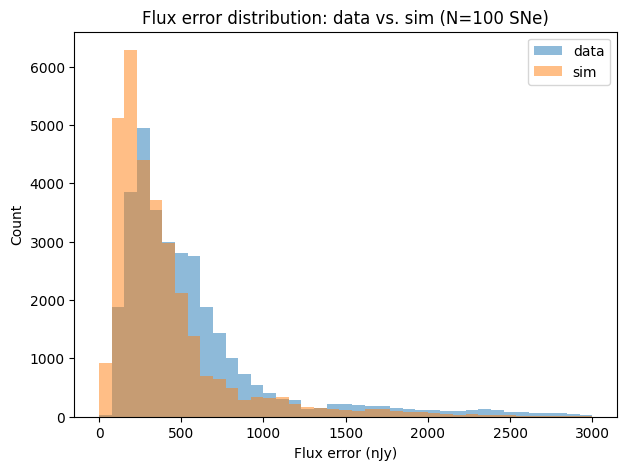

In [41]:
# Histogram of flux uncertainties: real data vs. simulation, aggregated across all simulated SNe
all_sim_fluxerr = pd.concat(
    [results.iloc[i]["lightcurve"]["fluxerr"] for i in range(len(results))], ignore_index=True
)
all_data_fluxerr = pd.concat(
    [pd.DataFrame(data.iloc[i]["diaObjectForcedSource_dia_object_lc"])["psfDiffFluxErr"]
     for i in range(len(results))],
    ignore_index=True,
)

bins = np.linspace(0, 3000, 40)
plt.figure(figsize=(7, 5))
plt.hist(all_data_fluxerr, bins=bins, alpha=0.5, label="data")
plt.hist(all_sim_fluxerr, bins=bins, alpha=0.5, label="sim")
plt.xlabel("Flux error (nJy)")
plt.ylabel("Count")
plt.title(f"Flux error distribution: data vs. sim (N={len(results)} SNe)")
plt.legend()
plt.show()

In [42]:
print("Median data_err/sim_err:",np.nanmedian(all_data_fluxerr/all_sim_fluxerr))

Median data_err/sim_err: 1.506041745067695
